In [43]:
def scatter(pred_df, true_df, title, xlabel, ylabel, r, rho, mse):
    x = true_df.squeeze()
    y = pred_df.squeeze() 
    
    plt.figure(figsize=(6, 6))
    plt.xlim(0, 4)
    plt.ylim(0, 4)
    plt.plot([0, 4], [0, 4], color='#015088', linestyle='--', label='y = x')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.scatter(x, y, alpha=0.2)
    plt.xlabel(f'{xlabel}')
    plt.ylabel(f'{ylabel}')
    plt.title(f'{title}')

    textstr = f'$r$ = {r:.2f}\n$\\rho$ = {rho:.2f}\nmse = {mse:.2f}'
    plt.text(0.07, 0.93, textstr, transform=plt.gca().transAxes,
         fontsize=16, verticalalignment='top')
    plt.grid(True)
    # plt.savefig(f"{thesis_dir}{direc}{title.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

ENFORMER_OUT = '/home/azstephe/liverRegression/regression_liver/data/enformer_outputs'


In [7]:
target_track = 205
# load enformer output
preds_raw = np.load(f"{ENFORMER_OUT}/log_test2/pig_liver_TEST_enformer_{str(target_track)}_predictions_test.npy")

# Take the average across the 896 bins for each entry
# This gives you a 1D array of length N
preds_avg = np.mean(preds_raw, axis=1).flatten()

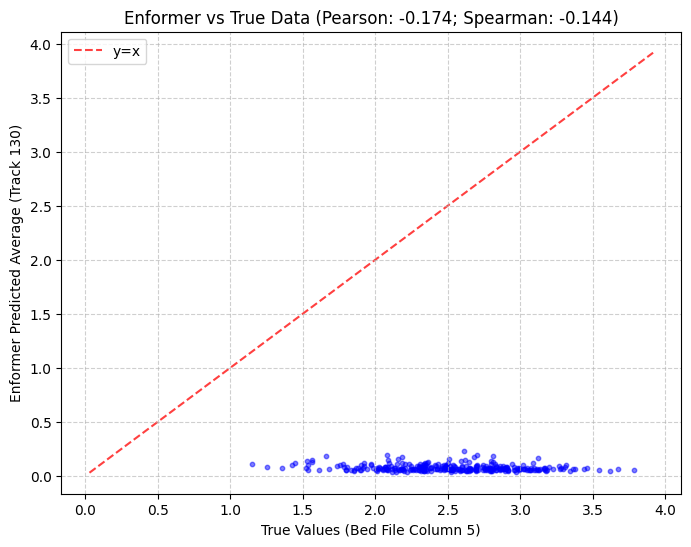

In [8]:
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [5]:
target_track = 205
# load enformer output
preds_raw = np.load(f"{ENFORMER_OUT}/log_test2/pig_liver_TEST_enformer_{str(target_track)}_predictions.npy")

# Take the average across the 896 bins for each entry
# This gives you a 1D array of length N
preds_avg = np.mean(preds_raw, axis=1).flatten()

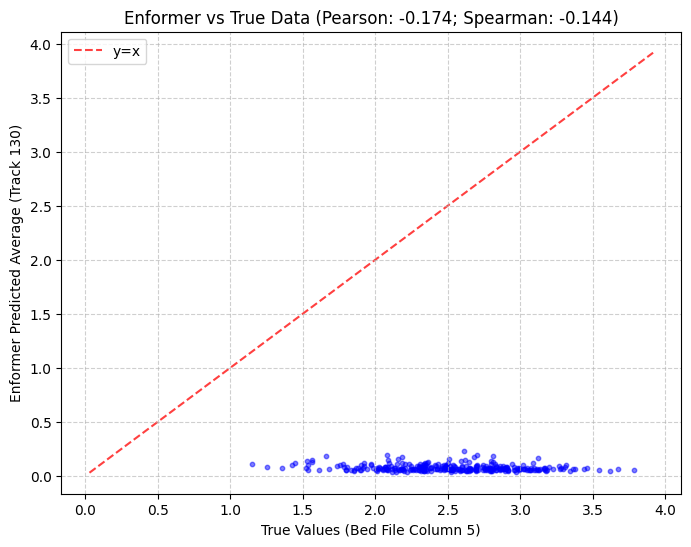

In [6]:
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

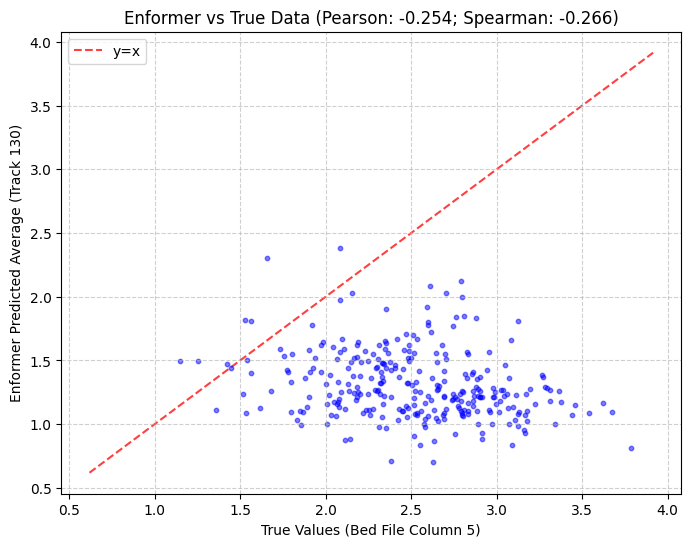

In [20]:
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

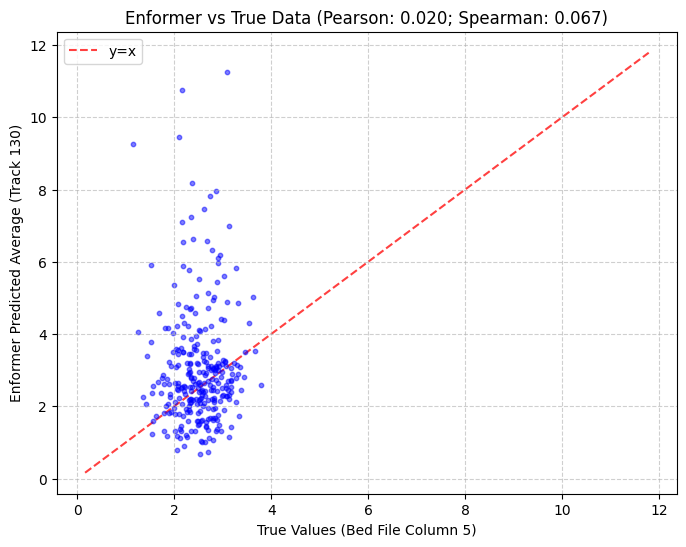

In [10]:
preds_middle_4 = preds_raw[:, 446:450]

# 3. Take the average across those 4 bins
# axis=1 collapses the 4 bins into one average value
preds_avg = np.mean(preds_middle_4, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

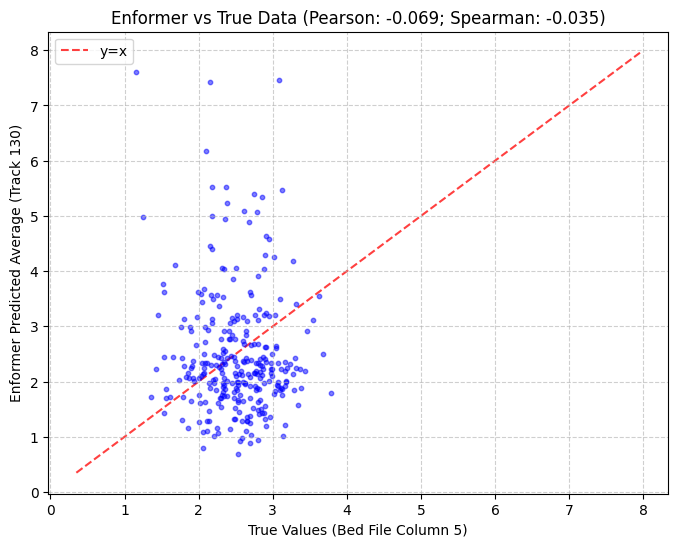

In [13]:
preds_middle_8 = preds_raw[:, 444:452]

# 3. Take the average across those 4 bins
# axis=1 collapses the 4 bins into one average value
preds_avg = np.mean(preds_middle_8, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

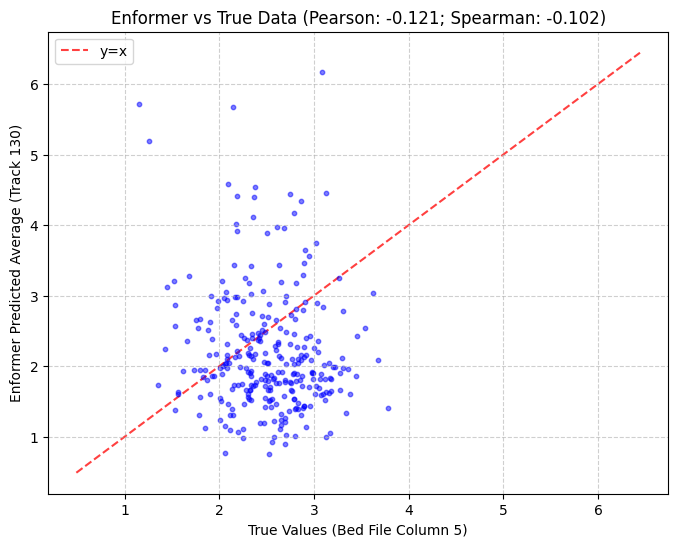

In [12]:
preds_middle_12 = preds_raw[:, 442:454]

# 3. Take the average across those 4 bins
# axis=1 collapses the 4 bins into one average value
preds_avg = np.mean(preds_middle_12, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [21]:
target_track = 205
# load enformer output
preds_raw = np.load(f"{ENFORMER_OUT}/log_test2/pig_liver_TEST_enformer_{str(target_track)}_predictions.npy")

# Take the average across the 896 bins for each entry
# This gives you a 1D array of length N
preds_avg = np.mean(preds_raw, axis=1).flatten()
preds_avg

array([0.06062299, 0.05585609, 0.0769994 , 0.0743554 , 0.07569633,
       0.07684754, 0.04660174, 0.05321414, 0.06169068, 0.11833608,
       0.16426635, 0.17937014, 0.06282034, 0.05352377, 0.04679077,
       0.07540681, 0.11310948, 0.06142458, 0.07212978, 0.05287562,
       0.05724862, 0.06110845, 0.06429324, 0.06281013, 0.04983842,
       0.05526932, 0.05195537, 0.058849  , 0.05425724, 0.0536637 ,
       0.05549752, 0.05111902, 0.05312292, 0.05870314, 0.070023  ,
       0.03831708, 0.08183207, 0.07748258, 0.05670428, 0.07716923,
       0.17962268, 0.19344063, 0.06336693, 0.04728833, 0.06469031,
       0.04836422, 0.05026018, 0.09160284, 0.09362433, 0.09724715,
       0.09594025, 0.06375383, 0.05982402, 0.08989031, 0.09434442,
       0.13226864, 0.11858058, 0.19011508, 0.14695494, 0.14087442,
       0.05133051, 0.05178748, 0.05429783, 0.037727  , 0.06336025,
       0.07324985, 0.06857503, 0.11049662, 0.11178589, 0.06472788,
       0.07193162, 0.07260738, 0.05838165, 0.0726182 , 0.07484

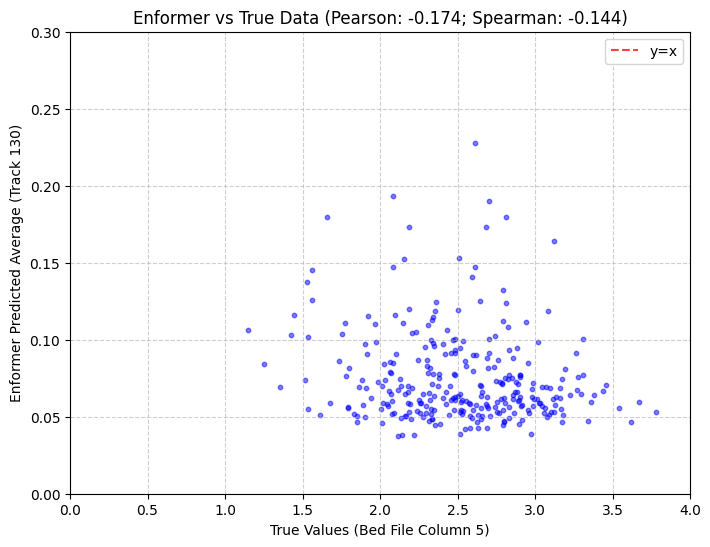

In [27]:
preds_avg = np.mean(preds_raw, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(0, 4, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlim(0, 4)
plt.ylim(0, 0.3)

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

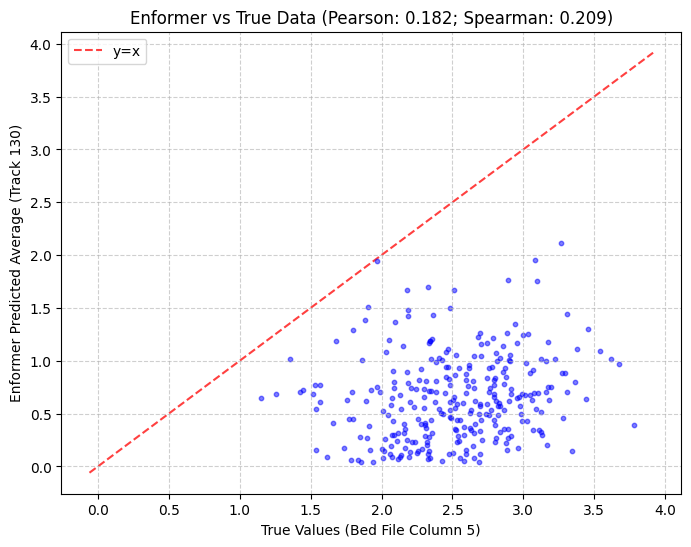

In [15]:
preds_middle_4 = preds_raw[:, 446:450]

# 3. Take the average across those 4 bins
# axis=1 collapses the 4 bins into one average value
preds_avg = np.mean(preds_middle_4, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

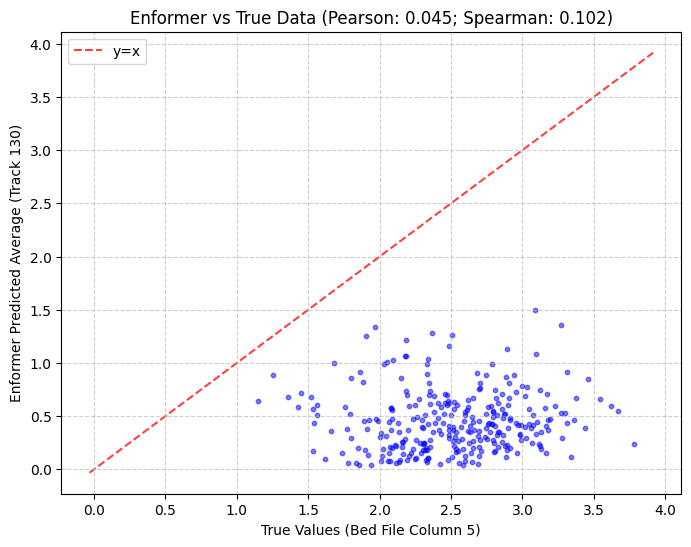

In [16]:
preds_middle_8 = preds_raw[:, 444:452]

# 3. Take the average across those 4 bins
# axis=1 collapses the 4 bins into one average value
preds_avg = np.mean(preds_middle_8, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

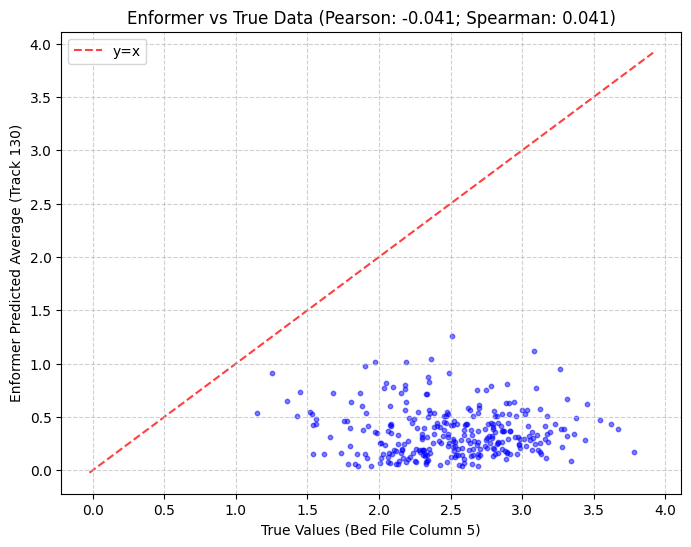

In [17]:
preds_middle_12 = preds_raw[:, 442:454]

# 3. Take the average across those 4 bins
# axis=1 collapses the 4 bins into one average value
preds_avg = np.mean(preds_middle_12, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

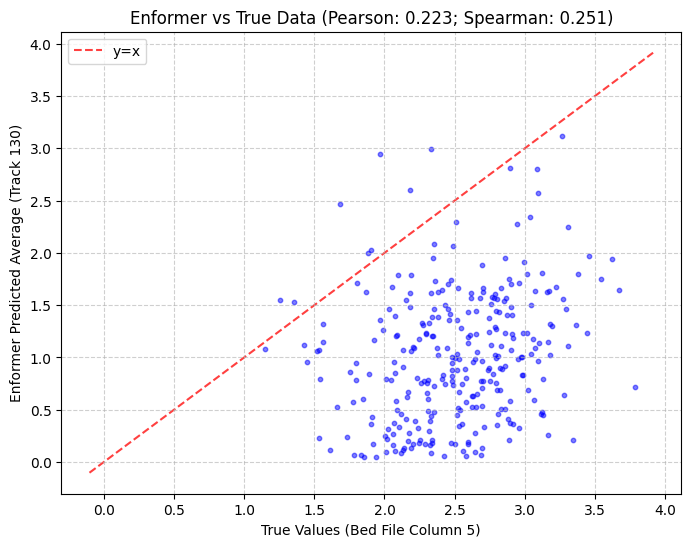

In [23]:
preds_middle_4 = preds_raw[:, 446:450]

# 3. Take the average across those 4 bins
# axis=1 collapses the 4 bins into one average value
preds_avg = np.max(preds_middle_4, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

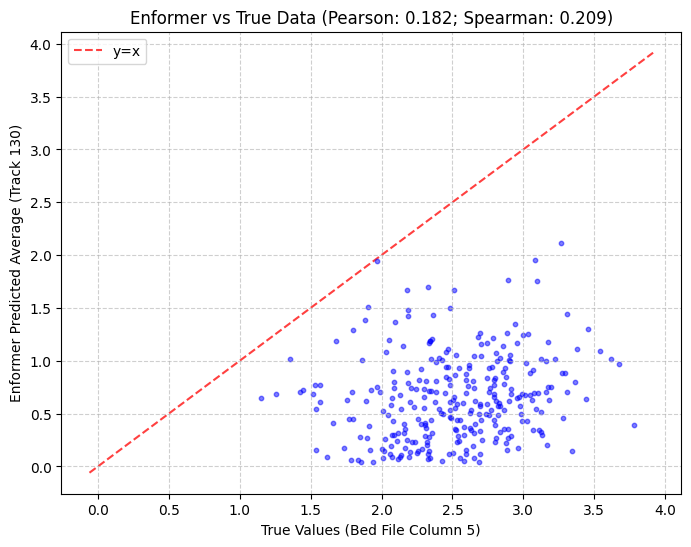

In [24]:
preds_middle_4 = preds_raw[:, 446:450]

# 3. Take the average across those 4 bins
# axis=1 collapses the 4 bins into one average value
preds_avg = np.mean(preds_middle_4, axis=1).flatten()

# 3. Load the true values from the .bed file
species = "pig" # adjust as needed
bed_path = f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed'
true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

# 4. Verify the 1-to-1 ratio
if len(preds_avg) != len(true_values):
    print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
    # Adjust length if necessary to match the smaller set
    min_len = min(len(preds_avg), len(true_values))
    preds_avg = preds_avg[:min_len]
    true_values = true_values[:min_len]

# 5. Calculate Correlation (Pearson R)
pearson, pearson_p = pearsonr(true_values, preds_avg)
spearman, spearman_p = spearmanr(true_values, preds_avg)

# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)

# Add a diagonal identity line (y=x) for reference
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel('True Values (Bed File Column 5)')
plt.ylabel('Enformer Predicted Average (Track 130)')
plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from pathlib import Path
import os

ENFORMER_OUT = Path('/home/azstephe/liverRegression/regression_liver/data/enformer_outputs')
ENFORMER_INPUTS = Path('/home/azstephe/liverRegression/regression_liver/data/enformer_inputs/')
target_track = 205


/home/azstephe/liverRegression/regression_liver/data/enformer_outputs/log_test2/pig_liver_TEST_enformer_205_preds.npy
/home/azstephe/liverRegression/regression_liver/data/enformer_inputs/log_test2/pig_liver_TEST_500bp.bed


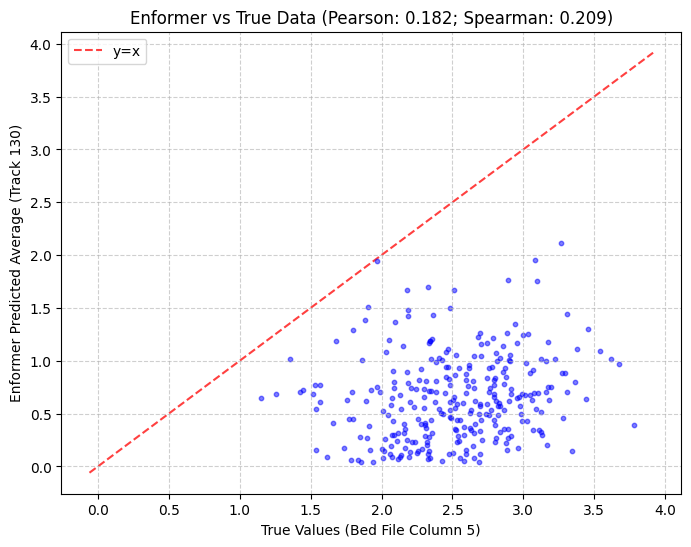

/home/azstephe/liverRegression/regression_liver/data/enformer_outputs/log_test2/macaque_liver_TEST_enformer_205_preds.npy
/home/azstephe/liverRegression/regression_liver/data/enformer_inputs/log_test2/macaque_liver_TEST_500bp.bed


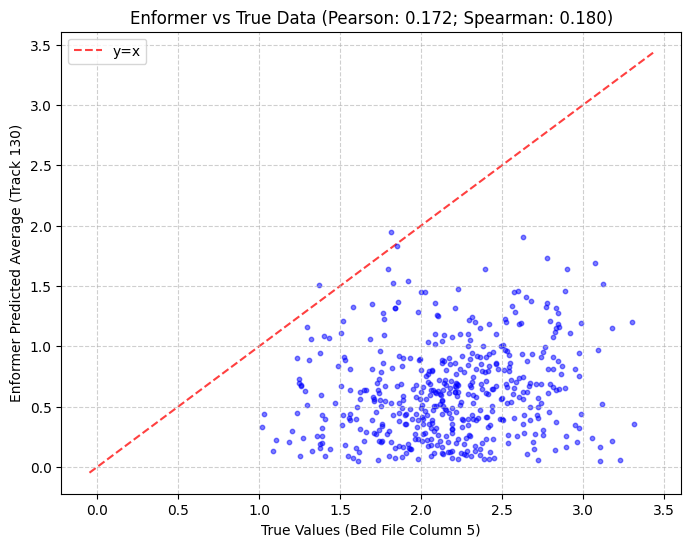

/home/azstephe/liverRegression/regression_liver/data/enformer_outputs/log_test2/cow_liver_TEST_enformer_205_preds.npy
/home/azstephe/liverRegression/regression_liver/data/enformer_inputs/log_test2/cow_liver_TEST_500bp.bed


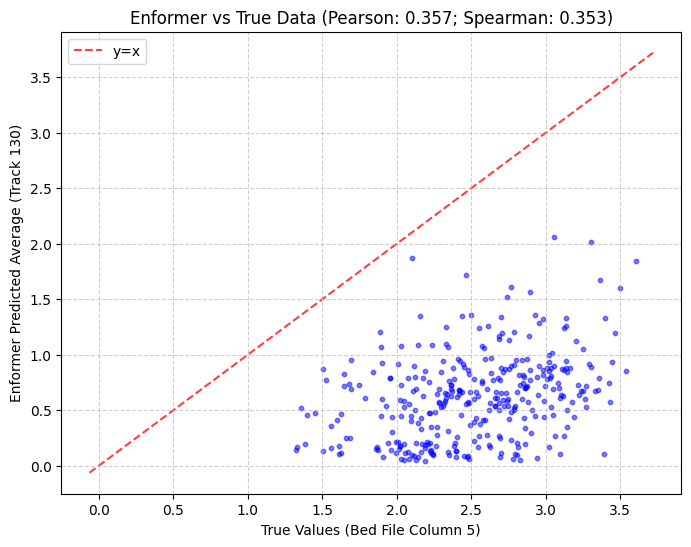

/home/azstephe/liverRegression/regression_liver/data/enformer_outputs/log_test2/rat_liver_TEST_enformer_205_preds.npy
/home/azstephe/liverRegression/regression_liver/data/enformer_inputs/log_test2/rat_liver_TEST_500bp.bed


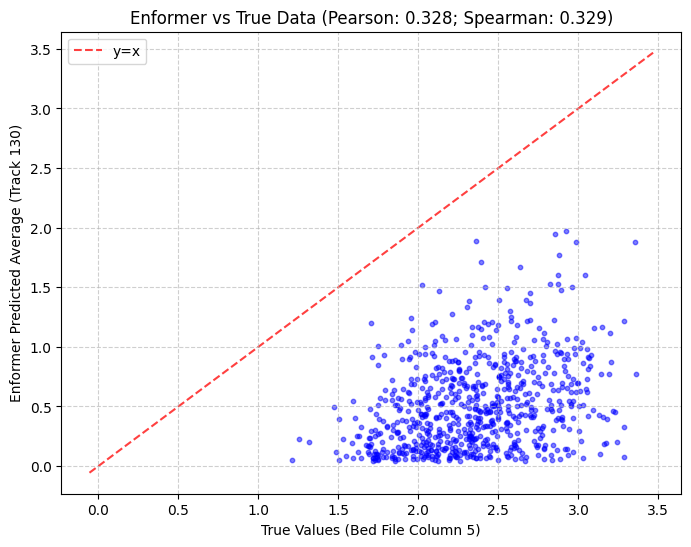

In [49]:
dir_list = ['log_test2']
for subdir_name in dir_list:
# for subdir_name in os.listdir(ENFORMER_OUT):
    subdir_path = ENFORMER_OUT / subdir_name
    if not subdir_path.is_dir(): continue

    for pred_path in subdir_path.glob("*_205_preds.npy"):
        species = pred_path.name.split('_')[0]
        preds_raw = np.load(pred_path)
        preds_middle_4 = preds_raw[:, 446:450]
        preds_avg = np.mean(preds_middle_4, axis=1).flatten()

        # True values
        bed_path = ENFORMER_INPUTS / subdir_name / f'{species}_liver_TEST_500bp.bed'
        # print(bed_path)
        true_values = pd.read_csv(bed_path, header=None, delim_whitespace=True).iloc[:, 4].values

        print(pred_path)
        print(bed_path)
        
        # 4. Verify the 1-to-1 ratio
        if len(preds_avg) != len(true_values):
            print(f"Warning: Size mismatch! Preds: {len(preds_avg)}, True: {len(true_values)}")
            # Adjust length if necessary to match the smaller set
            min_len = min(len(preds_avg), len(true_values))
            preds_avg = preds_avg[:min_len]
            true_values = true_values[:min_len]
        
        # 5. Calculate Correlation (Pearson R)
        pearson, pearson_p = pearsonr(true_values, preds_avg)
        spearman, spearman_p = spearmanr(true_values, preds_avg)
        
        # 6. Plotting
        plt.figure(figsize=(8, 6))
        plt.scatter(true_values, preds_avg, alpha=0.5, color='blue', s=10)
        
        # Add a diagonal identity line (y=x) for reference
        lims = [
            np.min([plt.xlim(), plt.ylim()]),  # min of both axes
            np.max([plt.xlim(), plt.ylim()]),  # max of both axes
        ]
        plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='y=x')
        
        plt.xlabel('True Values (Bed File Column 5)')
        plt.ylabel('Enformer Predicted Average (Track 130)')
        plt.title(f'Enformer vs True Data (Pearson: {pearson:.3f}; Spearman: {spearman:.3f})')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()


        
        # final_output = np.array(results)

        # stem = fasta_path.stem.replace("_500bp", "")
        # out_subdir = ENFORMER_OUTPUTS / subdir_name
        # out_subdir.mkdir(parents=True, exist_ok=True)

        # save_path = out_subdir / f"{stem}_enformer_{target_track}_preds.npy"
        # np.save(save_path, final_output)

In [61]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

results_list = []
neg_results = []

dir_list = ['log_test2', 'log_test1']

for subdir_name in dir_list:
    subdir_path = ENFORMER_OUT / subdir_name
    if not subdir_path.is_dir(): 
        continue

    # --- PATH A: Negative Controls ---
    species_neg_collector = {}
        
    for pred_path in subdir_path.glob("*_205_preds.npy"):
        # Extract species (e.g., 'human' or 'mouse') from the filename
        species = pred_path.name.split('_')[0]
            
        preds_raw = np.load(pred_path) # shape (N, 896)
        # Average the center 4 bins for each sequence in this file
        avg_per_seq = np.mean(preds_raw[:, 446:450], axis=1)
            
        if species not in species_neg_collector:
            species_neg_collector[species] = []
            
        species_neg_collector[species].extend(avg_per_seq)
        
        # After checking all files in the subdir, calculate stats for each species
    for species, all_preds in species_neg_collector.items():
        if all_preds:
            neg_results.append({
                'subdir': subdir_name,
                'species': species,
                'global_avg': np.mean(all_preds),
                'std_dev': np.std(all_preds),
                'count': len(all_preds)
            })
            print(f"Processed {subdir_name} - {species} as Negative Control.", flush=True)

    # --- PATH B: Standard Positive Correlation ---
    if subdir_name not in ['log_test1', 'neg']:
        for pred_path in subdir_path.glob("*_205_preds.npy"):
            species = pred_path.name.split('_')[0]
            preds_raw = np.load(pred_path)
            preds_avg = np.mean(preds_raw[:, 446:450], axis=1).flatten()

            bed_path = ENFORMER_INPUTS / subdir_name / f'{species}_liver_TEST_500bp.bed'
            if not bed_path.exists(): continue
            
            true_values = pd.read_csv(bed_path, header=None, sep=r'\s+').iloc[:, 4].values

            if len(preds_avg) != len(true_values):
                min_len = min(len(preds_avg), len(true_values))
                preds_avg, true_values = preds_avg[:min_len], true_values[:min_len]
            
            if len(preds_avg) > 1:
                r, p = pearsonr(true_values, preds_avg)
                s, sp = spearmanr(true_values, preds_avg)
                results_list.append({
                    'subdir': subdir_name, 'species': species,
                    'pearson_r': r, 'pearson_p': p, 'spearman_rho': s, 'spearman_p': sp, 'n': len(preds_avg)
                })

# pd.DataFrame(results_list).to_csv("/home/azstephe/liverRegression/regression_liver/data/enformer_meta/correlations.tsv", sep='\t', index=False)
# pd.DataFrame(neg_results).to_csv("/home/azstephe/liverRegression/regression_liver/data/enformer_meta/all_metadata.tsv", sep='\t', index=False)

Processed log_test2 - pig as Negative Control.
Processed log_test2 - macaque as Negative Control.
Processed log_test2 - cow as Negative Control.
Processed log_test2 - rat as Negative Control.
Processed log_test1 - pig as Negative Control.
Processed log_test1 - macaque as Negative Control.
Processed log_test1 - rat as Negative Control.
Processed log_test1 - cow as Negative Control.


In [62]:
pd.DataFrame(results_list)

,subdir,species,pearson_r,pearson_p,spearman_rho,spearman_p,n
0,log_test2,pig,0.182331,1.724561e-03,0.208793,3.201587e-04,293
1,log_test2,macaque,0.172249,1.696294e-04,0.179813,8.556710e-05,472
2,log_test2,cow,0.357104,1.529001e-11,0.352843,2.756805e-11,336
3,log_test2,rat,0.328264,1.261492e-19,0.329280,9.600337e-20,723


In [63]:
pd.DataFrame(neg_results)

,subdir,species,global_avg,std_dev,count
0,log_test2,pig,0.653782,0.403259,293
1,log_test2,macaque,0.625410,0.385508,472
2,log_test2,cow,0.622894,0.384818,336
3,log_test2,rat,0.512130,0.372566,723
4,log_test1,pig,0.085432,0.092261,871
5,log_test1,macaque,0.081815,0.082231,1155
6,log_test1,rat,0.108069,0.136878,1241
7,log_test1,cow,0.085004,0.092804,1096
